In [1]:
import torch
import torch.nn as nn
import math
import torch.nn.functional as F

In [37]:
def calculate_masked_attention(query:torch.Tensor, keys: torch.Tensor, values: torch.Tensor, mask:torch.Tensor):
    keys_transpose = keys.transpose(-1,-2)
    similary = torch.matmul(query,keys_transpose)
    similary = similary/math.sqrt(query.shape[-1])
    if mask is not None:
        similary = torch.where(mask == 0, -1e9, similary)
    similary_soft = F.softmax(similary, dim=-1)
    # order is important
    # q,k,v = (batches, num_patches, embed_size)
    # sftmax(q*k/sqrt(d)) = (batches,num_patches,num_patches)
    # attention = (batches, num_patches, embed_size)
    attention = torch.matmul(similary_soft,values)
    return attention

In [5]:
class FeedForward(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.layer1 = nn.Linear(embed_size, embed_size)
        self.layer2 = nn.Linear(embed_size, embed_size)
    

    def forward(self, x: torch.Tensor):
        x = self.layer1(x)
        x = F.gelu(x)
        x = self.layer2(x)
        return x


In [34]:
class AttentionLayer(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.embed_size = embed_size
        self.query = nn.Linear(embed_size, embed_size)
        self.keys = nn.Linear(embed_size, embed_size)
        self.values = nn.Linear(embed_size, embed_size)
    
    def forward(self, x):
        q = self.query(x)
        k = self.keys(x)
        v = self.values(x)
        return calculate_masked_attention(q,k,v,None)


In [30]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        self.attention = AttentionLayer(embed_size)
        self.mlp = FeedForward(embed_size)
        self.layerNorm = nn.LayerNorm(embed_size)

    def forward(self, input):
        x = self.attention(input)
        x = self.layerNorm(x)
        x = self.mlp(x)
        x = F.gelu(x)
        output = x+input
        return output

In [8]:
class Transformer(nn.Module):
    def __init__(self, embed_size, num_layers):
        super().__init__()
        self.tranformerBlocks = nn.ModuleList([TransformerBlock(embed_size) for _ in range(num_layers)])
    
    def forward(self, x):
        for block in self.tranformerBlocks:
            x = block(x)
        return x

In [12]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, embed_size, max_seq_length):
        super().__init__()
        position = torch.arange(max_seq_length).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, embed_size, 2) * (-math.log(10000.0) / embed_size))

        pe = torch.zeros(max_seq_length, embed_size)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer('positional_embedding', pe)

    def forward(self, x):
        return x + self.positional_embedding[:, :x.size(1), :]

In [13]:
torch.randn(1,1,10)

tensor([[[ 0.8001,  0.9275, -1.3640,  1.5754,  0.2743,  1.0034, -2.5219,
           0.7350,  0.5519, -1.0364]]])

In [24]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, channels, embed_size,layers):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size//patch_size) ** 2
        self.positional_encoding = SinusoidalPositionalEncoding(embed_size,self.num_patches+1)
        # use Conv2d to split image into patches 
        # input channels, output channels, kernel_size = stride so image is split without overlapz
        self.patch_embed = nn.Conv2d(channels,embed_size, kernel_size=patch_size, stride=patch_size)
        self.cls_token_index = 0

        # cls token will be trained by model
        self.cls_token = nn.Parameter(torch.randn(1,1,embed_size))
        self.transformer = Transformer(embed_size,layers)

    def forward(self, image):
        # image = (batches, channels, height, width)
        batches = image.shape[0]

        # (batches, embed_size, height/patch_size, width/patch_size)
        # output channels are embed_size, so that many kernels are used
        # number of patches are height/size, width/size
        # each kernel dot products with part of image, sums to generate single number
        x = self.patch_embed(image)

        # flatten everything from 2nd dimension to 1
        # (batches, embed_size, num_patches)
        x = x.flatten(2)

        # (batches, num_patches, embed_size)
        x = x.transpose(1,2)

        # clstoken = (batches, 1, embed_size)
        clstoken = self.cls_token.expand(batches,-1,-1)

        # add cls token at beginning
        x = torch.cat((clstoken,x), dim=1)

        # add pos encoding
        x = self.positional_encoding(x)

        x = self.transformer(x)

        return x


In [27]:
class VITClassifier(nn.Module):
    def __init__(self, image_size, patch_size, channels, embed_size,layers, num_classes):
        super().__init__()
        self.vit = VisionTransformer(image_size, patch_size, channels, embed_size,layers)
        self.mlp = nn.Linear(embed_size, num_classes)
    
    def forward(self, x):
        # pass through vision transformer
        x = self.vit(x)

        # use cls token for class prediction
        logits = self.mlp(x[:,0,:])

        # dont apply softmax in forward pass
        # mostly we use CrossEntropyLoss during training, and behind the hood it computes
        # softmax and updates gradients
        # if we do softmax here, we are applying it twice which will be a problem
        return logits 

In [35]:
image = torch.randn(1,1,28,28)
vit = VITClassifier(image_size=28,patch_size=4, channels=1, embed_size=14, layers=4,num_classes=10)
output = vit(image)
print(output.shape)

torch.Size([1, 10])


In [40]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define the transformations
transform = transforms.Compose([
    transforms.ToTensor()
])

# 2. Download and load the data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [41]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vit.parameters(), lr=0.001)

In [44]:
for step in range(10):
    for x,y in train_loader:
        output = vit(x)
        loss_val = loss(output,y)
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

In [57]:
for test_x,test_y in test_loader:
    test_x = test_x
    pred = vit(test_x)
    pred = F.softmax(pred, dim=-1)

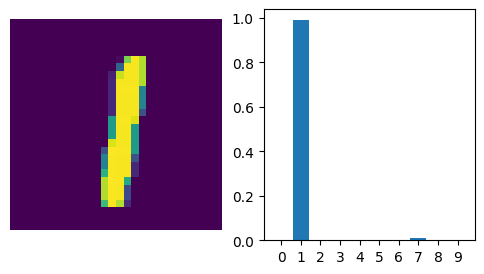

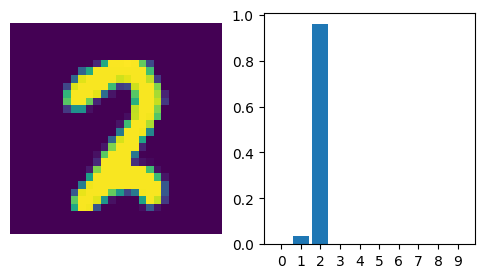

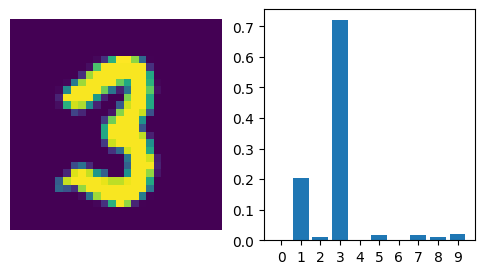

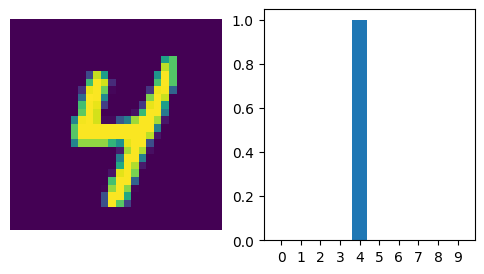

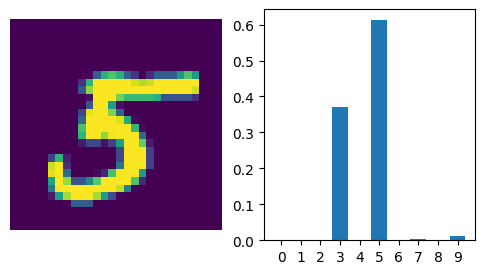

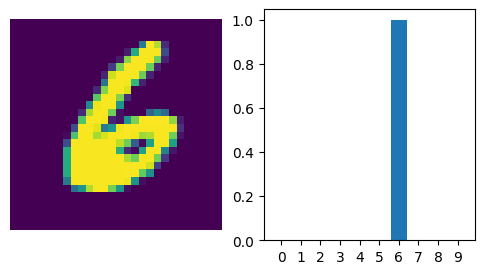

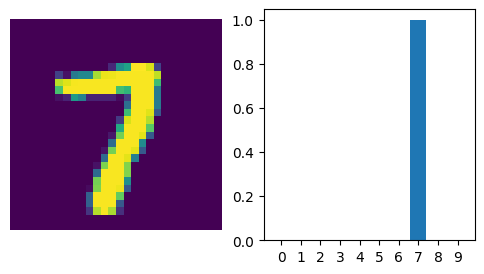

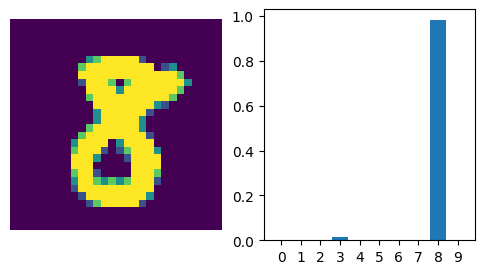

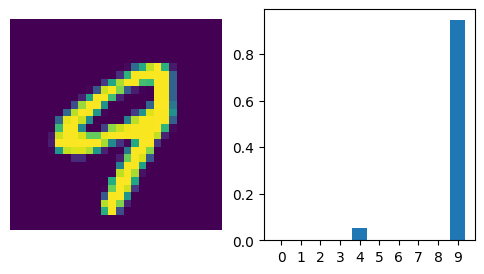

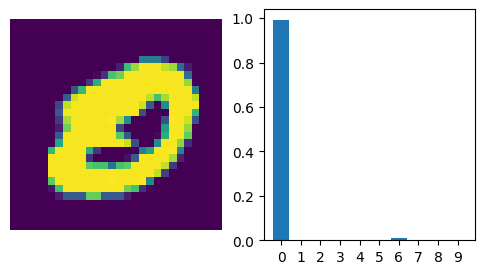

In [59]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(10):
    fig,axs = plt.subplots(1,2,figsize=(6,3))
    axs[0].axis("off")
    axs[0].imshow(test_x[i][0].view(28,28).detach().numpy())
    axs[1].bar(np.arange(10), pred[i].detach().numpy())
    axs[1].set_xticks(np.arange(10))

plt.show()